# Data Cleansing
Data cleansing consists of following 3 processes usally<br> 
* Missing Values
* Outlier Values
* Duplidated values

## Missing value handling

Pandas treat None and NaN as essentially interchangeable for indicating missing or null values. To facilitate this convention, there are several useful functions for detecting, removing, and replacing null values in Pandas DataFrame :

* isnull()
* notnull()
* dropna()
* fillna()
* replace()
* interpolate()

* For predictive analysis, the data cleansing work is mandatory before loading the data into the forecasting models. We need to remove all the dirty data such as nulls, duplicates, outliers. For descriptive analysis, nulls might be allowed in some dashboard. (E.G., the agent details chart)

In [1]:
## From SQL to DataFrame Pandas
import pandas as pd
import os
import time

In [2]:
os.chdir(r"../data/raw")
ccbis_files=os.listdir()
createVar = locals()
for i in ccbis_files:
    if i.endswith("csv"):
        createVar[i.split('.')[0]] = pd.read_csv(i)

## Data overview

In [3]:
# dataframe CDR
CDR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CDRID             16000 non-null  int64 
 1   CustomerKey       16000 non-null  int64 
 2   AgentKey          16000 non-null  int64 
 3   CallDate          16000 non-null  object
 4   Start_TM          16000 non-null  object
 5   End_TM            16000 non-null  object
 6   Status            16000 non-null  object
 7   Satisfaction      16000 non-null  int64 
 8   FirstResolved     16000 non-null  int64 
 9   HandleType_Key    16000 non-null  int64 
 10  ServiceType_Key   16000 non-null  int64 
 11  SeverityType_Key  16000 non-null  int64 
 12  CallReason_Key    16000 non-null  int64 
 13  NPS               16000 non-null  int64 
 14  ProductKey        16000 non-null  int64 
 15  CustomerTier      16000 non-null  object
 16  CustomerSegment   16000 non-null  object
 17  CloseDate   

## Count the Null Columns

In [4]:
null_columns=CDR.columns[CDR.isnull().any()]
CDR[null_columns].isnull().sum()

Series([], dtype: float64)

If there are lots of different columns containing null values. What if we want to find specific row and column which has null?

## Single Column Is Null

In [5]:
print(CDR[CDR["Status"].isnull()][null_columns])

Empty DataFrame
Columns: []
Index: []


And what if we want to return every row that contains at least one null value? That’s not too difficult – it’s just a combination of the code in the previous two sections.

## All Null Columns

In [6]:
print(CDR[CDR.isnull().any(axis=1)][null_columns].head())

Empty DataFrame
Columns: []
Index: []


## Let's check other tables

In [7]:
# dataframe DimAgent
DimAgent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   AgentID    100 non-null    int64 
 1   FirstName  100 non-null    object
 2   LastName   100 non-null    object
 3   Group      100 non-null    object
 4   Location   100 non-null    object
dtypes: int64(1), object(4)
memory usage: 4.0+ KB


In [8]:
null_columns=DimAgent.columns[DimAgent.isnull().any()]
DimAgent[null_columns].isnull().sum()

Series([], dtype: float64)

In [9]:
print(DimAgent[DimAgent.isnull().any(axis=1)][null_columns].head())

Empty DataFrame
Columns: []
Index: []


In [10]:
# dataframe DimCustomer (This table has lots of NULL)
DimCustomer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18484 entries, 0 to 18483
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerKey           18484 non-null  int64  
 1   GeographyKey          18484 non-null  int64  
 2   CustomerAlternateKey  18484 non-null  object 
 3   Title                 101 non-null    object 
 4   FirstName             18484 non-null  object 
 5   MiddleName            10654 non-null  object 
 6   LastName              18484 non-null  object 
 7   NameStyle             18484 non-null  bool   
 8   BirthDate             18484 non-null  object 
 9   MaritalStatus         18484 non-null  object 
 10  Suffix                3 non-null      object 
 11  Gender                18484 non-null  object 
 12  EmailAddress          18484 non-null  object 
 13  YearlyIncome          18484 non-null  float64
 14  TotalChildren         18484 non-null  int64  
 15  NumberChildrenAtHom

In [11]:
null_columns=DimCustomer.columns[DimCustomer.isnull().any()]
DimCustomer[null_columns].isnull().sum()

Title           18383
MiddleName       7830
Suffix          18481
AddressLine2    18172
dtype: int64

In [12]:
print(DimCustomer[DimCustomer.isnull().any(axis=1)][null_columns].head())

  Title MiddleName Suffix AddressLine2
0   NaN          V    NaN          NaN
1   NaN          L    NaN          NaN
2   NaN        NaN    NaN          NaN
3   NaN        NaN    NaN          NaN
4   NaN        NaN    NaN          NaN


In [13]:
# dataframe DimGeography
DimGeography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 655 entries, 0 to 654
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   GeographyKey              655 non-null    int64 
 1   City                      655 non-null    object
 2   StateProvinceCode         655 non-null    object
 3   StateProvinceName         655 non-null    object
 4   CountryRegionCode         655 non-null    object
 5   EnglishCountryRegionName  655 non-null    object
 6   SpanishCountryRegionName  655 non-null    object
 7   FrenchCountryRegionName   655 non-null    object
 8   PostalCode                655 non-null    object
 9   SalesTerritoryKey         655 non-null    int64 
dtypes: int64(2), object(8)
memory usage: 51.3+ KB


In [14]:
null_columns=DimGeography.columns[DimGeography.isnull().any()]
DimGeography[null_columns].isnull().sum()

Series([], dtype: float64)

In [15]:
# dataframe DimHandleType
DimHandleType.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   HandleType_Key   3 non-null      int64 
 1   HandleType_Desc  3 non-null      object
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes


In [16]:
null_columns=DimHandleType.columns[DimHandleType.isnull().any()]
DimHandleType[null_columns].isnull().sum()

Series([], dtype: float64)

In [17]:
# dataframe DimProduct
DimProduct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product_Key       25 non-null     int64 
 1   Name              25 non-null     object
 2   ProductGroup_Key  25 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 732.0+ bytes


In [18]:
null_columns=DimProduct.columns[DimProduct.isnull().any()]
DimProduct[null_columns].isnull().sum()

Series([], dtype: float64)

In [19]:
# dataframe DimProductGroup
DimProductGroup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ProductGroup_Key  5 non-null      int64 
 1   Name              5 non-null      object
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes


In [20]:
null_columns=DimProductGroup.columns[DimProductGroup.isnull().any()]
DimProductGroup[null_columns].isnull().sum()

Series([], dtype: float64)

In [21]:
# dataframe DimServiceType
DimServiceType.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ServiceType_Key   16 non-null     int64 
 1   ServiceType_Desc  16 non-null     object
dtypes: int64(1), object(1)
memory usage: 388.0+ bytes


In [22]:
null_columns=DimServiceType.columns[DimServiceType.isnull().any()]
DimServiceType[null_columns].isnull().sum()

Series([], dtype: float64)

In [23]:
# dataframe DimSeverifyType
DimSeverifyType.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SeverityType_Key   3 non-null      int64 
 1   SeverityType_Desc  3 non-null      object
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes


In [24]:
null_columns=DimSeverifyType.columns[DimSeverifyType.isnull().any()]
DimSeverifyType[null_columns].isnull().sum()

Series([], dtype: float64)

# Find and remove duplicated rows

In [25]:
import pandas as pd

In [26]:
df=pd.read_csv('CDR.csv')

In [27]:
df.head()

,CDRID,CustomerKey,AgentKey,CallDate,Start_TM,End_TM,Status,Satisfaction,FirstResolved,HandleType_Key,ServiceType_Key,SeverityType_Key,CallReason_Key,NPS,ProductKey,CustomerTier,CustomerSegment,CloseDate
0,1,11569,69,2019-01-06,2019-01-06 02:29:01,2019-01-06 02:34:01,Processed,5,1,2,1,2,15,0,5,PlatinumElite,Segment C,2019-01-09
1,2,11847,9,2019-01-02,2019-01-02 23:10:59,2019-01-02 23:20:59,Processed,3,1,3,14,1,6,8,6,Platinum,Segment D,2019-01-05
2,3,11081,39,2019-01-06,2019-01-06 08:00:33,2019-01-06 08:05:33,Processed,5,0,2,9,1,13,0,9,Gold,Segment B,2019-01-13
3,4,11871,46,2019-01-06,2019-01-06 04:16:00,2019-01-06 04:26:00,Processed,5,1,3,14,1,5,7,3,Platinum,Segment E,2019-01-09
4,5,11192,90,2019-01-03,2019-01-03 17:15:15,2019-01-03 17:20:15,Processed,3,0,3,12,3,8,6,8,Gold,Segment C,2019-01-08


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
(~df.duplicated()).sum()

np.int64(16000)

In [30]:
df=pd.read_csv('DimAgent.csv')

In [31]:
df.head()

,AgentID,FirstName,LastName,Group,Location
0,1,Jarrod,Todd,Level 1,London
1,2,Chancellor,Mckenzie,Level 1,Berlin
2,3,Lamar,Pace,Level 5,London
3,4,Brenden,Nguyen,Level 5,Paris
4,5,Micah,Gilbert,Level 2,Paris


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df=pd.read_csv('DimCustomer.csv')

In [34]:
df.head()

,CustomerKey,GeographyKey,CustomerAlternateKey,Title,FirstName,MiddleName,LastName,NameStyle,BirthDate,MaritalStatus,...,EnglishOccupation,SpanishOccupation,FrenchOccupation,HouseOwnerFlag,NumberCarsOwned,AddressLine1,AddressLine2,Phone,DateFirstPurchase,CommuteDistance
0,11000,26,AW00011000,NaN,Jon,V,Yang,False,1966-04-08,M,...,Professional,Profesional,Cadre,1,0,3761 N. 14th St,NaN,1 (11) 500 555-0162,2001-07-22,1-2 Miles
1,11001,37,AW00011001,NaN,Eugene,L,Huang,False,1965-05-14,S,...,Professional,Profesional,Cadre,0,1,2243 W St.,NaN,1 (11) 500 555-0110,2001-07-18,0-1 Miles
2,11002,31,AW00011002,NaN,Ruben,NaN,Torres,False,1965-08-12,M,...,Professional,Profesional,Cadre,1,1,5844 Linden Land,NaN,1 (11) 500 555-0184,2001-07-10,2-5 Miles
3,11003,11,AW00011003,NaN,Christy,NaN,Zhu,False,1968-02-15,S,...,Professional,Profesional,Cadre,0,1,1825 Village Pl.,NaN,1 (11) 500 555-0162,2001-07-01,5-10 Miles
4,11004,19,AW00011004,NaN,Elizabeth,NaN,Johnson,False,1968-08-08,S,...,Professional,Profesional,Cadre,1,4,7553 Harness Circle,NaN,1 (11) 500 555-0131,2001-07-26,1-2 Miles


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df=pd.read_csv('DimGeography.csv')

In [37]:
df.head()

,GeographyKey,City,StateProvinceCode,StateProvinceName,CountryRegionCode,EnglishCountryRegionName,SpanishCountryRegionName,FrenchCountryRegionName,PostalCode,SalesTerritoryKey
0,1,Alexandria,NSW,New South Wales,AU,Australia,Australia,Australie,2015,9
1,2,Coffs Harbour,NSW,New South Wales,AU,Australia,Australia,Australie,2450,9
2,3,Darlinghurst,NSW,New South Wales,AU,Australia,Australia,Australie,2010,9
3,4,Goulburn,NSW,New South Wales,AU,Australia,Australia,Australie,2580,9
4,5,Lane Cove,NSW,New South Wales,AU,Australia,Australia,Australie,1597,9


In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df=pd.read_csv('DimHandleType.csv')

In [40]:
df.head()

,HandleType_Key,HandleType_Desc
0,1,Call
1,2,Chat
2,3,Email


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df=pd.read_csv('DimServiceType.csv')

In [43]:
df.head()

,ServiceType_Key,ServiceType_Desc
0,1,Billing Issue
1,2,Contact Information Change
2,3,Delivery Issue
3,4,Contact Cancellation Request
4,5,Functionality Question


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df=pd.read_csv('DimSeverifyType.csv')

In [46]:
df.head()

,SeverityType_Key,SeverityType_Desc
0,1,High
1,2,Low
2,3,Medium


In [47]:
df.duplicated().sum()

np.int64(0)

# Data Manipulation (Data Wrangling)

## Data Cleansing of DimCustomer

### Handling missing values in Title column of DimCustomer

In [48]:
# Replacing the missing values in Title column of DimCustomer Table
DimCustomer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18484 entries, 0 to 18483
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerKey           18484 non-null  int64  
 1   GeographyKey          18484 non-null  int64  
 2   CustomerAlternateKey  18484 non-null  object 
 3   Title                 101 non-null    object 
 4   FirstName             18484 non-null  object 
 5   MiddleName            10654 non-null  object 
 6   LastName              18484 non-null  object 
 7   NameStyle             18484 non-null  bool   
 8   BirthDate             18484 non-null  object 
 9   MaritalStatus         18484 non-null  object 
 10  Suffix                3 non-null      object 
 11  Gender                18484 non-null  object 
 12  EmailAddress          18484 non-null  object 
 13  YearlyIncome          18484 non-null  float64
 14  TotalChildren         18484 non-null  int64  
 15  NumberChildrenAtHom

In [49]:
DimCustomer[['Gender','MaritalStatus','Title']].apply(str)

Gender           0        M\n1        M\n2        M\n3        F...
MaritalStatus    0        M\n1        S\n2        M\n3        S...
Title            0        NaN\n1        NaN\n2        NaN\n3   ...
dtype: object

In [50]:
DimCustomer['Title']=DimCustomer['Title'].mask((DimCustomer['Gender'].map(lambda x : x=='F')) & (DimCustomer['MaritalStatus'].map(lambda x : x=='M')),'Mrs.')

In [51]:
DimCustomer['Title']=DimCustomer['Title'].mask((DimCustomer['Gender'].map(lambda x : x=='F')) & (DimCustomer['MaritalStatus'].map(lambda x : x=='S')),'Ms.')

In [52]:
DimCustomer['Title']=DimCustomer['Title'].mask((DimCustomer['Gender'].map(lambda x : x=='M')),'Mr.')

In [53]:
DimCustomer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18484 entries, 0 to 18483
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerKey           18484 non-null  int64  
 1   GeographyKey          18484 non-null  int64  
 2   CustomerAlternateKey  18484 non-null  object 
 3   Title                 18484 non-null  object 
 4   FirstName             18484 non-null  object 
 5   MiddleName            10654 non-null  object 
 6   LastName              18484 non-null  object 
 7   NameStyle             18484 non-null  bool   
 8   BirthDate             18484 non-null  object 
 9   MaritalStatus         18484 non-null  object 
 10  Suffix                3 non-null      object 
 11  Gender                18484 non-null  object 
 12  EmailAddress          18484 non-null  object 
 13  YearlyIncome          18484 non-null  float64
 14  TotalChildren         18484 non-null  int64  
 15  NumberChildrenAtHom

In [54]:
DimCustomer.duplicated().sum()

np.int64(0)

### Detecting outliers inYearlyIncome column of DimCustomer

In [55]:
import numpy as np
import matplotlib.pyplot as plt

In [56]:
q1=np.quantile(DimCustomer.YearlyIncome,0.25)
q3=np.quantile(DimCustomer.YearlyIncome,0.75)
med=np.median(DimCustomer.YearlyIncome)
IQR=q3-q1
upper_bound=q3+(1.5*IQR)
lower_bound=q1-(1.5*IQR)
print(IQR,upper_bound,lower_bound)

40000.0 130000.0 -30000.0


In [57]:
outliers=DimCustomer.YearlyIncome[(DimCustomer.YearlyIncome<lower_bound)|(DimCustomer.YearlyIncome>upper_bound)]
print('The following are outliers in the boxplot: {}'.format(outliers))

The following are outliers in the boxplot: 79       160000.0
80       170000.0
180      160000.0
181      170000.0
240      160000.0
           ...   
17960    160000.0
18221    150000.0
18222    160000.0
18238    150000.0
18239    150000.0
Name: YearlyIncome, Length: 309, dtype: float64


In [58]:
YearlyIncome=DimCustomer.YearlyIncome

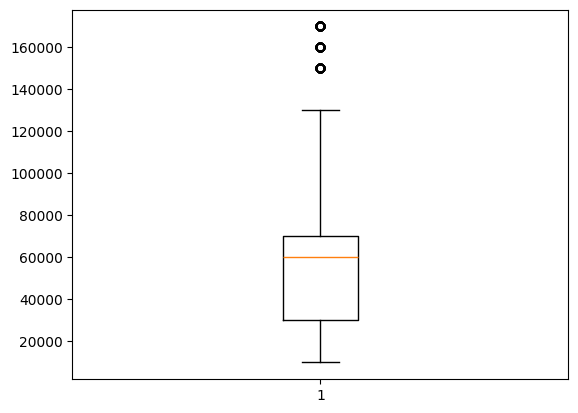

<Figure size 1000x700 with 0 Axes>

In [59]:
plt.boxplot(YearlyIncome)
fig=plt.figure(figsize=(10,7))
plt.show()

### Put cleansed data into DimCustomer.csv

In [60]:
# DON'T FORGET TO ADD index=False in the following code. Otherwise, it will generate an additional indexing column which will lead to error when loading data into sql. 

In [62]:
import os
os.getcwd()

'C:\\HG_Portfolio\\Data-Analyst-Portfolio\\Call-Centre-Business-Intelligence-System\\data\\raw'

In [63]:
DimCustomer.to_csv(r"../../data/processed/DimCustomer.csv",index=False)

In [64]:
DimCustomer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18484 entries, 0 to 18483
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerKey           18484 non-null  int64  
 1   GeographyKey          18484 non-null  int64  
 2   CustomerAlternateKey  18484 non-null  object 
 3   Title                 18484 non-null  object 
 4   FirstName             18484 non-null  object 
 5   MiddleName            10654 non-null  object 
 6   LastName              18484 non-null  object 
 7   NameStyle             18484 non-null  bool   
 8   BirthDate             18484 non-null  object 
 9   MaritalStatus         18484 non-null  object 
 10  Suffix                3 non-null      object 
 11  Gender                18484 non-null  object 
 12  EmailAddress          18484 non-null  object 
 13  YearlyIncome          18484 non-null  float64
 14  TotalChildren         18484 non-null  int64  
 15  NumberChildrenAtHom

In [65]:
DimCustomer.head()

,CustomerKey,GeographyKey,CustomerAlternateKey,Title,FirstName,MiddleName,LastName,NameStyle,BirthDate,MaritalStatus,...,EnglishOccupation,SpanishOccupation,FrenchOccupation,HouseOwnerFlag,NumberCarsOwned,AddressLine1,AddressLine2,Phone,DateFirstPurchase,CommuteDistance
0,11000,26,AW00011000,Mr.,Jon,V,Yang,False,1966-04-08,M,...,Professional,Profesional,Cadre,1,0,3761 N. 14th St,NaN,1 (11) 500 555-0162,2001-07-22,1-2 Miles
1,11001,37,AW00011001,Mr.,Eugene,L,Huang,False,1965-05-14,S,...,Professional,Profesional,Cadre,0,1,2243 W St.,NaN,1 (11) 500 555-0110,2001-07-18,0-1 Miles
2,11002,31,AW00011002,Mr.,Ruben,NaN,Torres,False,1965-08-12,M,...,Professional,Profesional,Cadre,1,1,5844 Linden Land,NaN,1 (11) 500 555-0184,2001-07-10,2-5 Miles
3,11003,11,AW00011003,Ms.,Christy,NaN,Zhu,False,1968-02-15,S,...,Professional,Profesional,Cadre,0,1,1825 Village Pl.,NaN,1 (11) 500 555-0162,2001-07-01,5-10 Miles
4,11004,19,AW00011004,Ms.,Elizabeth,NaN,Johnson,False,1968-08-08,S,...,Professional,Profesional,Cadre,1,4,7553 Harness Circle,NaN,1 (11) 500 555-0131,2001-07-26,1-2 Miles


## Data Cleansing of CDR

### Correcting the data types of CDR relevant date/time columns

In [66]:
CDR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CDRID             16000 non-null  int64 
 1   CustomerKey       16000 non-null  int64 
 2   AgentKey          16000 non-null  int64 
 3   CallDate          16000 non-null  object
 4   Start_TM          16000 non-null  object
 5   End_TM            16000 non-null  object
 6   Status            16000 non-null  object
 7   Satisfaction      16000 non-null  int64 
 8   FirstResolved     16000 non-null  int64 
 9   HandleType_Key    16000 non-null  int64 
 10  ServiceType_Key   16000 non-null  int64 
 11  SeverityType_Key  16000 non-null  int64 
 12  CallReason_Key    16000 non-null  int64 
 13  NPS               16000 non-null  int64 
 14  ProductKey        16000 non-null  int64 
 15  CustomerTier      16000 non-null  object
 16  CustomerSegment   16000 non-null  object
 17  CloseDate   

In [67]:
CDR['CallDate']=pd.to_datetime(CDR['CallDate'])
CDR['Start_TM']=pd.to_datetime(CDR['Start_TM'])
CDR['End_TM']=pd.to_datetime(CDR['End_TM'])
CDR['CloseDate']=pd.to_datetime(CDR['CloseDate'])

In [68]:
CDR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CDRID             16000 non-null  int64         
 1   CustomerKey       16000 non-null  int64         
 2   AgentKey          16000 non-null  int64         
 3   CallDate          16000 non-null  datetime64[ns]
 4   Start_TM          16000 non-null  datetime64[ns]
 5   End_TM            16000 non-null  datetime64[ns]
 6   Status            16000 non-null  object        
 7   Satisfaction      16000 non-null  int64         
 8   FirstResolved     16000 non-null  int64         
 9   HandleType_Key    16000 non-null  int64         
 10  ServiceType_Key   16000 non-null  int64         
 11  SeverityType_Key  16000 non-null  int64         
 12  CallReason_Key    16000 non-null  int64         
 13  NPS               16000 non-null  int64         
 14  ProductKey        1600

In [69]:
CDR.duplicated().sum()

np.int64(0)

  ### Handling Outliers in CDR Table -- using IQR Rules

### Detecting outliers in NPS column of CDR

In [70]:
q1=np.quantile(CDR.NPS,0.25)
q3=np.quantile(CDR.NPS,0.75)
med=np.median(CDR.NPS)
IQR=q3-q1
upper_bound=q3+(1.5*IQR)
lower_bound=q1-(1.5*IQR)
print(IQR,upper_bound,lower_bound)

7.0 19.5 -8.5


In [71]:
outliers=CDR.NPS[(CDR.NPS<lower_bound)|(CDR.NPS>upper_bound)]
print('The following are outliers in the boxplot: {}'.format(outliers))

The following are outliers in the boxplot: Series([], Name: NPS, dtype: int64)


In [72]:
NPS=CDR.NPS

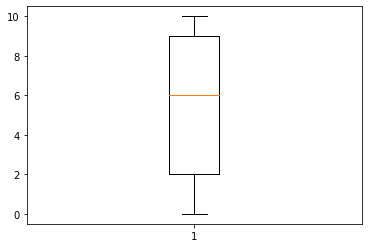

<Figure size 720x504 with 0 Axes>

In [70]:
plt.boxplot(NPS)
fig=plt.figure(figsize=(10,7))
plt.show()

### Put cleansed data into CDR.csv

In [74]:
CDR.to_csv(r"../../data/processed/CDR.csv",index=False)

In [75]:
CDR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CDRID             16000 non-null  int64         
 1   CustomerKey       16000 non-null  int64         
 2   AgentKey          16000 non-null  int64         
 3   CallDate          16000 non-null  datetime64[ns]
 4   Start_TM          16000 non-null  datetime64[ns]
 5   End_TM            16000 non-null  datetime64[ns]
 6   Status            16000 non-null  object        
 7   Satisfaction      16000 non-null  int64         
 8   FirstResolved     16000 non-null  int64         
 9   HandleType_Key    16000 non-null  int64         
 10  ServiceType_Key   16000 non-null  int64         
 11  SeverityType_Key  16000 non-null  int64         
 12  CallReason_Key    16000 non-null  int64         
 13  NPS               16000 non-null  int64         
 14  ProductKey        1600

In [76]:
CDR.head()

,CDRID,CustomerKey,AgentKey,CallDate,Start_TM,End_TM,Status,Satisfaction,FirstResolved,HandleType_Key,ServiceType_Key,SeverityType_Key,CallReason_Key,NPS,ProductKey,CustomerTier,CustomerSegment,CloseDate
0,1,11569,69,2019-01-06,2019-01-06 02:29:01,2019-01-06 02:34:01,Processed,5,1,2,1,2,15,0,5,PlatinumElite,Segment C,2019-01-09
1,2,11847,9,2019-01-02,2019-01-02 23:10:59,2019-01-02 23:20:59,Processed,3,1,3,14,1,6,8,6,Platinum,Segment D,2019-01-05
2,3,11081,39,2019-01-06,2019-01-06 08:00:33,2019-01-06 08:05:33,Processed,5,0,2,9,1,13,0,9,Gold,Segment B,2019-01-13
3,4,11871,46,2019-01-06,2019-01-06 04:16:00,2019-01-06 04:26:00,Processed,5,1,3,14,1,5,7,3,Platinum,Segment E,2019-01-09
4,5,11192,90,2019-01-03,2019-01-03 17:15:15,2019-01-03 17:20:15,Processed,3,0,3,12,3,8,6,8,Gold,Segment C,2019-01-08


# ETL data into CCBISDW

## Generate dataframe from CSV

In [78]:
## From SQL to DataFrame Pandas
import pandas as pd
import pyodbc
import os
import pandas as pd
# !pip install sqlalchemy
import sqlalchemy

from sqlalchemy import create_engine, MetaData, Table, select
from six.moves import urllib

os.chdir(r"../../data/processed")
ccbis_files=os.listdir()
createVar = locals()
for i in ccbis_files:
    if i.endswith("csv"):
        createVar[i.split('.')[0]] = pd.read_csv(i)

## Create a database connection engine

In [79]:
params = urllib.parse.quote_plus("DRIVER={ODBC Driver 17 for SQL Server};SERVER=localhost;DATABASE=CCBISDW;UID=sa;PWD=SQLServer2019")
engine = sqlalchemy.create_engine("mssql+pyodbc:///?odbc_connect=%s" % params) 
engine.connect() 

## Load DimAgent Table

In [ ]:
DimAgent.to_sql(name='DimAgent',con=engine, index=False, if_exists='append')

## Load DimServerifyType table

In [ ]:
DimSeverifyType.to_sql(name='DimSeverifyType',con=engine, index=False, if_exists='append')

## Load DimServiceType Table

In [ ]:
DimServiceType.to_sql(name='DimServiceType',con=engine, index=False, if_exists='append')

## Load DimHandleType Table

In [ ]:
DimHandleType.to_sql(name='DimHandleType',con=engine, index=False, if_exists='append')

## Load DimProduct Table

In [ ]:
DimProductGroup.columns = ['ProductGroup_Key','ProductGroup']
DimPro = pd.merge(DimProduct,DimProductGroup, on='ProductGroup_Key')
DimPro = DimPro[['Product_Key','Name','ProductGroup']]
DimPro.to_sql(name='DimProduct',con=engine, index=False, if_exists='append')

## Load Dimcustomer Table 

In [ ]:
#DimProductGroup.columns = ['ProductGroup_Key','ProductGroup']
DimCust = pd.merge(DimCustomer,DimGeography, on='GeographyKey')

In [ ]:
DimCust = DimCust.loc[:, DimCust.columns != 'GeographyKey']

In [ ]:
DimCust.to_sql(name='DimCustomer',con=engine, index=False, if_exists='append')

## Load FactCDR

In [ ]:
CDR.to_sql(name='FactCDR',con=engine, index=False, if_exists='append')

In [ ]:
DimCustomer.head()

In [ ]:
CDR.head()